In [2]:
import pandas as pd
import seaborn as sns

In [3]:
house_data = pd.read_csv("HousePricePrediction.csv")
house_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [4]:
house = house_data.dropna(subset=["SalePrice"])

In [20]:
X = house.drop(columns=["SalePrice","Id"])
y = house["SalePrice"]

In [21]:
X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0


In [22]:
X.select_dtypes(include="object").columns

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X.isnull().sum()

MSSubClass             0
LotArea                0
OverallCond            0
YearBuilt              0
YearRemodAdd           0
BsmtFinSF2             0
TotalBsmtSF            0
MSZoning_FV            0
MSZoning_RH            0
MSZoning_RL            0
MSZoning_RM            0
LotConfig_CulDSac      0
LotConfig_FR2          0
LotConfig_FR3          0
LotConfig_Inside       0
BldgType_2fmCon        0
BldgType_Duplex        0
BldgType_Twnhs         0
BldgType_TwnhsE        0
Exterior1st_AsphShn    0
Exterior1st_BrkComm    0
Exterior1st_BrkFace    0
Exterior1st_CBlock     0
Exterior1st_CemntBd    0
Exterior1st_HdBoard    0
Exterior1st_ImStucc    0
Exterior1st_MetalSd    0
Exterior1st_Plywood    0
Exterior1st_Stone      0
Exterior1st_Stucco     0
Exterior1st_VinylSd    0
Exterior1st_Wd Sdng    0
Exterior1st_WdShing    0
dtype: int64

In [25]:
X["BsmtFinSF2"] = X["BsmtFinSF2"].fillna(X["BsmtFinSF2"].median())
X["TotalBsmtSF"] = X["TotalBsmtSF"].fillna(X["TotalBsmtSF"].median())



In [26]:
X

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,20,9600,8,1976,1976,0.0,1262.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,60,11250,5,2001,2002,0.0,920.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,70,9550,5,1915,1970,0.0,756.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,60,14260,5,2000,2000,0.0,1145.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,7917,5,1999,2000,0.0,953.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1456,20,13175,6,1978,1988,163.0,1542.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1457,70,9042,9,1941,2006,0.0,1152.0,False,False,True,...,True,False,False,False,False,False,False,False,False,False
1458,20,9717,6,1950,1996,1029.0,1078.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [27]:
y.isnull().sum()

np.int64(0)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [29]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (1168, 33)
X_test: (292, 33)
y_train: (1168,)
y_test: (292,)


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()

In [32]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = model.predict(X_test)

In [36]:
y_pred[:10]

array([168844.20187049, 243627.93266265, 114499.46802618, 157672.74928538,
       254809.7269156 , 156499.88714211, 177912.63550297, 127514.41651571,
       133133.47244363, 149402.60951097])

In [37]:
y_test[:10]

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
614      75500.0
218     311500.0
1160    146000.0
649      84500.0
887     135500.0
Name: SalePrice, dtype: float64

In [38]:
comparison = pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted Price":y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,154500.0,168844.201870
1,325000.0,243627.932663
2,115000.0,114499.468026
3,159000.0,157672.749285
4,315500.0,254809.726916
5,75500.0,156499.887142
6,311500.0,177912.635503
7,146000.0,127514.416516
8,84500.0,133133.472444
9,135500.0,149402.609511


In [39]:
comparison["Difference"] = comparison["Actual Price"] - comparison["Predicted Price"]

comparison.head(10)

,Actual Price,Predicted Price,Difference
0,154500.0,168844.201870,-14344.201870
1,325000.0,243627.932663,81372.067337
2,115000.0,114499.468026,500.531974
3,159000.0,157672.749285,1327.250715
4,315500.0,254809.726916,60690.273084
5,75500.0,156499.887142,-80999.887142
6,311500.0,177912.635503,133587.364497
7,146000.0,127514.416516,18485.583484
8,84500.0,133133.472444,-48633.472444
9,135500.0,149402.609511,-13902.609511


In [42]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("R2 Score :",r2)
print("MAE :",mae)
print("RMSE :",rmse)



R2 Score : 0.6195131796544807
MAE : 34122.85443215004
RMSE : 54022.75473895732


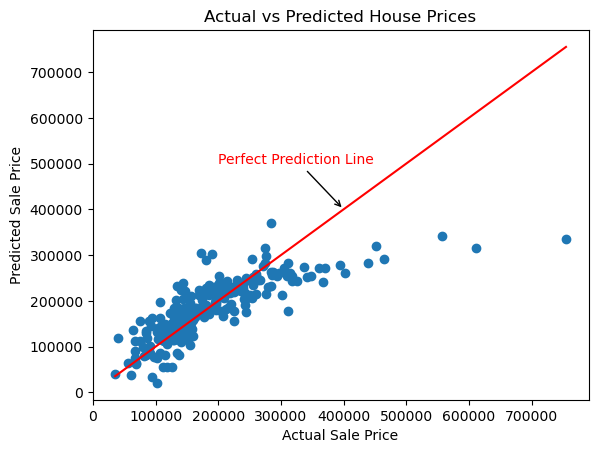

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],color="red"
)

plt.annotate(
    "Perfect Prediction Line",
    xy=(400000, 400000),
    xytext=(200000, 500000),
    arrowprops=dict(arrowstyle="->"),
    color="red"
)

plt.show()